In [1]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [2]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("1. Loading raw datasets (Skipping bad lines)...")
fake_df = pd.read_csv('Fake.csv', on_bad_lines='skip', engine='python')
true_df = pd.read_csv('True.csv', on_bad_lines='skip', engine='python')

true_df['label'] = 1
fake_df['label'] = 0

print("2. Merging and Cleaning...")
combined_df = pd.concat([true_df, fake_df], ignore_index=True)
combined_df['cleaned_text'] = combined_df['text'].apply(clean_text)

# Drop any rows where cleaning left empty strings
combined_df = combined_df.dropna(subset=['cleaned_text'])

# Split the data (80% Training, 20% Testing)
X = combined_df['cleaned_text']
y = combined_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data ready! Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

1. Loading raw datasets (Skipping bad lines)...
2. Merging and Cleaning...
Data ready! Training samples: 35918 | Testing samples: 8980


1. Vectorizing text using TF-IDF...
2. Training Random Forest model... (This may take a minute)
3. Generating Evaluation Metrics...

--- Random Forest Evaluation ---
Accuracy:  0.9965

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00      4650
    Real (1)       1.00      1.00      1.00      4330

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



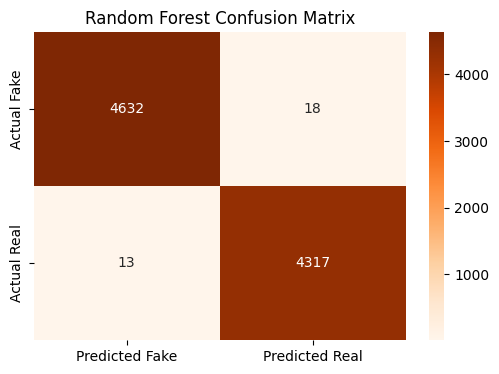

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("1. Vectorizing text using TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("2. Training Random Forest model... (This may take a minute)")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

print("3. Generating Evaluation Metrics...\n")
y_pred_rf = rf_model.predict(X_test_tfidf)

print("--- Random Forest Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Fake (0)', 'Real (1)']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.title('Random Forest Confusion Matrix')
plt.show()

In [4]:
import joblib
# Save the Random Forest model
joblib.dump(rf_model, 'random_forest_model.pkl')
# Save the TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, 'rf_tfidf_vectorizer.pkl')
print("Random Forest model and vectorizer exported successfuly!")

Random Forest model and vectorizer exported successfuly!


In [3]:
# 1. Uninstall the broken version and force a stable release
!pip uninstall -y transformers
!pip install transformers==4.38.2 tf-keras

# 2. Tell TensorFlow to behave BEFORE importing it
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# 3. Now import everything
import tensorflow as tf
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

print(f"Imports successful! Using TensorFlow version: {tf.__version__}")

print("1. Loading DistilBERT Tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenize data (Limiting to 128 tokens)
MAX_LEN = 128
X_train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=MAX_LEN, return_tensors='tf')
X_test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=MAX_LEN, return_tensors='tf')

# Convert labels to tensors
y_train_tf = tf.convert_to_tensor(list(y_train))
y_test_tf = tf.convert_to_tensor(list(y_test))

print("2. Building DistilBERT Model...")
bert_model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
bert_model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

print("3. Fine-Tuning BERT... (This will take a few minutes)")
bert_model.fit(
    dict(X_train_encodings), y_train_tf,
    epochs=2,
    batch_size=16,
    validation_data=(dict(X_test_encodings), y_test_tf)
)

print("\n4. Evaluating BERT...")
predictions = bert_model.predict(dict(X_test_encodings))
y_pred_bert = np.argmax(predictions.logits, axis=1)

print("--- BERT Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_bert):.4f}")

# Save the model and tokenizer to a folder
bert_model.save_pretrained('./truthguard_bert_model')
tokenizer.save_pretrained('./truthguard_bert_model')
print("\nDistilBERT Model and Tokenizer saved locally to ./truthguard_bert_model folder!")

Found existing installation: transformers 5.13.1
Uninstalling transformers-5.13.1:
  Successfully uninstalled transformers-5.13.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 86.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 req

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

2. Building DistilBERT Model...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

3. Fine-Tuning BERT... (This will take a few minutes)
Epoch 1/2
2245/2245 [==============================] - 566s 239ms/step - loss: 0.0140 - accuracy: 0.9968 - val_loss: 0.0113 - val_accuracy: 0.9979
Epoch 2/2
2245/2245 [==============================] - 533s 237ms/step - loss: 0.0047 - accuracy: 0.9991 - val_loss: 0.0101 - val_accuracy: 0.9984

4. Evaluating BERT...
281/281 [==============================] - 42s 142ms/step
--- BERT Evaluation ---
Accuracy:  0.9984

DistilBERT Model and Tokenizer saved locally to ./truthguard_bert_model folder!


In [4]:
!zip -r truthguard_bert_model.zip ./truthguard_bert_model

  adding: truthguard_bert_model/ (stored 0%)
  adding: truthguard_bert_model/tf_model.h5 (deflated 8%)
  adding: truthguard_bert_model/tokenizer_config.json (deflated 75%)
  adding: truthguard_bert_model/vocab.txt (deflated 53%)
  adding: truthguard_bert_model/special_tokens_map.json (deflated 42%)
  adding: truthguard_bert_model/config.json (deflated 44%)
